# Wrapper Feature selection using Particle Swarm Optimization.

El objetivo de este notebook es utilizar optimización por enjambre de partículas (PSO) para seleccionar, en cada acción, los indicadores financieros más relevantes a la hora de predecir el movimiento del precio de cierre día a día. Primero estableceremos las dependencias y constantes necesarias para el desarrollo del notebook.

In [2]:
import os
import pandas
import numpy
import sklearn.metrics
import pyswarms
import json

ROOT_DIR = os.path.abspath("..")
DATA_DIR = os.path.join(ROOT_DIR, "data") 

# Disable pyswarms logging
rep = pyswarms.utils.Reporter(log_path="/tmp/pyswarms.log")

Para cada una de las acciones disponibles en el directorio de datos, cargaremos los splits ya realizados de datos.

In [3]:
# Listar los TICKERS disponibles. Cada subdirectorio dentro de DATA_DIR corresponde a un TICKER.
tickers = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
# Cargamos en un diccionario los splits de datos para cada TICKER.
data = {}
for ticker in tickers:
    ticker_dir = os.path.join(DATA_DIR, ticker)
    data[ticker] = {
        "train": pandas.read_csv(os.path.join(ticker_dir, "train.csv"), index_col=0, parse_dates=True),
        "val": pandas.read_csv(os.path.join(ticker_dir, "val.csv"), index_col=0, parse_dates=True),
        "test": pandas.read_csv(os.path.join(ticker_dir, "test.csv"), index_col=0, parse_dates=True)
    }

Es necesario extraer la columna objetivo de los datos particionados.

In [4]:
processed_data = {}
for ticker, splits in data.items():
    processed_data[ticker] = {}
    for split_name, df in splits.items():
        # Extraer la columna objetivo "target" y almacenarla por separado.
        target = df["target"]
        features = df.drop(columns=["target"])
        processed_data[ticker][split_name] = {
            "features": features,
            "target": target
        }

Ahora, necesitaremos definir ciertas funciones auxiliares que utilizaremos para la optimización por enjambre de partículas. La siguiente función se encarga de evaluar todo el enjambre de partículas, calculando el coste (MSE) para cada partícula, es decir, para cada subconjunto de características que representa cada partícula.

In [5]:
def evaluate_swarm_regression(particles, X_train, y_train, X_val, y_val, model):
    n_particles = particles.shape[0]
    costs = numpy.zeros(n_particles)
    
    for i in range(n_particles):
        # Extraemos los índices de las características a evaluar.
        selected_features = numpy.where(particles[i] == 1)[0]
        
        # Si PSO decide apagar todas las métricas, le damos una penalización gigante.
        if len(selected_features) == 0:
            costs[i] = 1e9 
            continue
            
        # Filtramos para quedarnos solo con las métricas seleccionadas.
        X_train_filtered = X_train[:, selected_features]
        X_val_filtered = X_val[:, selected_features]
        
        # Entrenamos el modelo con este subconjunto.
        model.fit(X_train_filtered, y_train)
        
        # Predecimos el retorno del día siguiente en los datos de validación.
        preds = model.predict(X_val_filtered)
        
        # Calculamos el coste: Error Cuadrático Medio (MSE).
        costs[i] = sklearn.metrics.mean_squared_error(y_val, preds)
        
    return costs

Ahora podemos definir una función de optimización por ejambre que procese cada acción, realizando varias ejecuciones con diferentes semillas para obtener estadísticas más robustas. Esta función se encargará de ejecutar el proceso de optimización por enjambre de partículas, entrenar el modelo con las características seleccionadas y evaluar su rendimiento tanto en el conjunto de validación como en el conjunto de test.

In [6]:
def optimize_ticker(splits, model_base, n_particles, iters, n_runs=10):    
    # Extraccion de datos.
    X_train_df = splits['train']['features']
    y_train_series = splits['train']['target']
    X_val_df = splits['val']['features']
    y_val_series = splits['val']['target']
    X_test_df = splits['test']['features']
    y_test_series = splits['test']['target']
    
    def _drop_nan_rows(X_df, y_series):
        mask = X_df.notna().all(axis=1) & y_series.notna()
        return X_df.loc[mask], y_series.loc[mask]
    
    # Eliminar filas con NaN para evitar errores en el modelo y metricas.
    X_train_df, y_train_series = _drop_nan_rows(X_train_df, y_train_series)
    X_val_df, y_val_series = _drop_nan_rows(X_val_df, y_val_series)
    X_test_df, y_test_series = _drop_nan_rows(X_test_df, y_test_series)
    
    # Manejo de nombres de metricas.
    nombres_metricas = X_train_df.columns.values
    X_train = X_train_df.values
    X_val = X_val_df.values
    X_test = X_test_df.values
    y_train = numpy.asarray(y_train_series).ravel()
    y_val = numpy.asarray(y_val_series).ravel()
    y_test = numpy.asarray(y_test_series).ravel()
    
    # Configuracion de PSO.
    num_metricas_totales = X_train.shape[1]
    options = {'c1': 1.4, 'c2': 1.4, 'w': 0.7, 'k': n_particles, 'p': 2}
    
    # Para almacenar los resultados de las 10 ejecuciones con distintas semillas.
    resultados_ejecuciones = []
    
    # Bucle de las 10 ejecuciones con distinta semilla.
    for run in range(n_runs):
        # Semilla determinista.
        semilla = 42 + run
        numpy.random.seed(semilla) 
        
        # Inicializacion del optimizador PSO para seleccion de caracteristicas binaria.
        optimizer = pyswarms.discrete.binary.BinaryPSO(
            n_particles=n_particles,
            dimensions=num_metricas_totales,
            options=options
        )
        
        # Optimizacion.
        best_mse_val, best_mask = optimizer.optimize(
            evaluate_swarm_regression,
            iters=iters,
            verbose=False,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            model=model_base,
        )
        
        # Obtenemos las mejores metricas seleccionadas por PSO.
        indices_seleccionados = numpy.where(best_mask == 1)[0]
        
        # Si PSO fallo y no selecciono nada.
        if len(indices_seleccionados) == 0:
            mse_test = numpy.nan
        else:
            # Filtramos Train y Val para quedarnos solo con las caracteristicas seleccionadas
            X_train_sel = X_train[:, indices_seleccionados]
            X_val_sel = X_val[:, indices_seleccionados]
            X_test_sel = X_test[:, indices_seleccionados]
            
            # Unimos Train y Val para tener mas datos de entrenamiento (orden intacto)
            X_train_val = numpy.vstack((X_train_sel, X_val_sel))
            y_train_val = numpy.concatenate((y_train, y_val))
        
            # Entrenamos el modelo final con todos los datos disponibles.
            model_base.fit(X_train_val, y_train_val)
            
            # Evaluamos en el conjunto de Test.
            preds_test = model_base.predict(X_test_sel)
            mse_test = sklearn.metrics.mean_squared_error(y_test, preds_test)
        
        # Guardamos el historial de coste para visualizar el progreso del PSO.
        cost_history = [float(c) for c in optimizer.cost_history]
        resultados_ejecuciones.append({
            'semilla': semilla,
            'mse_val': float(best_mse_val),
            'mse_test': float(mse_test) if not numpy.isnan(mse_test) else numpy.nan,
            'mascara_binaria': best_mask,
            'cost_history': cost_history
        })
        
    # Metricas de esta semilla.
    df_resultados = pandas.DataFrame(resultados_ejecuciones)
    mejor_run = df_resultados.loc[df_resultados['mse_val'].idxmin()]
    mask_ganadora_global = mejor_run['mascara_binaria']
    metricas_ganadoras = nombres_metricas[numpy.where(mask_ganadora_global == 1)[0]]
    mse_val_promedio = df_resultados['mse_val'].mean()
    mse_test_promedio = df_resultados['mse_test'].mean()
    
    # Conversion a tipos serializables para JSON.
    estadisticas = []
    for row in resultados_ejecuciones:
        estadisticas.append({
            'semilla': int(row['semilla']),
            'mse_val': float(row['mse_val']) if not numpy.isnan(row['mse_val']) else None,
            'mse_test': float(row['mse_test']) if not numpy.isnan(row['mse_test']) else None,
            'mascara_binaria': row['mascara_binaria'].tolist(),
            'cost_history': row['cost_history']
        })
    
    return {
        'estadisticas': estadisticas,
        'mse_val_promedio': float(mse_val_promedio) if not numpy.isnan(mse_val_promedio) else None,
        'mse_test_promedio': float(mse_test_promedio) if not numpy.isnan(mse_test_promedio) else None,
        'mejor_mascara_absoluta': mask_ganadora_global.tolist(),
        'mejores_metricas': list(metricas_ganadoras)
    }

Finalmente, definimos una función que recorra todos los tickers en el diccionario principal y ejecute la optimización para cada uno, almacenando los resultados en un reporte final. Además, guardaremos los resultados de cada ticker en un archivo JSON para su posterior uso o análisis.

In [7]:
def run_pso_all_tickers(data_dict, model_base, n_particles=30, iters=100000, n_runs=10):
    reporte_final = {}  
    for ticker, splits in data_dict.items():
        # Ejecutamos la optimización por enjambre de partículas para este ticker.
        resultado_ticker = optimize_ticker(
            splits=splits,
            model_base=model_base,
            n_particles=n_particles,
            iters=iters,
            n_runs=n_runs
        )
        reporte_final[ticker] = resultado_ticker
        # Almacenar resultados en un json.
        path = os.path.join(DATA_DIR, ticker, "pso.json")
        with open(path, 'w') as f:
            json.dump(resultado_ticker, f)
    return reporte_final

Ahora, instanciamos como modelo base un RandomForestRegressor y ejecutamos la función que recorre todos los tickers, obteniendo un reporte con los resultados de la optimización por enjambre de partículas para cada acción.

In [7]:
# Modelo base: RandomForestRegressor.
model = sklearn.ensemble.RandomForestRegressor(n_estimators=15, random_state=42, criterion='friedman_mse', n_jobs=-1)
# Ejecutamos la optimización por enjambre de partículas para todos los tickers.
pso = run_pso_all_tickers(processed_data, model_base=model, n_particles=40, iters=100, n_runs=4)

Una vez ejecutado, leemos los JSON generados de vuelta para obtener los resultados de cada acción.


In [9]:
pso = {}
for ticker in tickers:
    path = os.path.join(DATA_DIR, ticker, "pso.json")
    with open(path, 'r') as f:
        pso[ticker] = json.load(f)

print(json.dumps(pso, indent=2))

{
  "AMZN": {
    "estadisticas": [
      {
        "semilla": 42,
        "mse_val": 3.4927962513743176,
        "mse_test": 6.388260629501592,
        "mascara_binaria": [
          1,
          1,
          0,
          0,
          1,
          0,
          0,
          0,
          0,
          0,
          0,
          0,
          0,
          0,
          0,
          0,
          0,
          0,
          1,
          1,
          0,
          1,
          1,
          0,
          1,
          1,
          1,
          0,
          0,
          0,
          1,
          0,
          0,
          1,
          1,
          1,
          0,
          1,
          1,
          1,
          0,
          0,
          0,
          1,
          1,
          0,
          1,
          0,
          0,
          1,
          1,
          0,
          0,
          0,
          1,
          1,
          1,
          0,
          1,
          0,
          0,
          1,
          1,
       

Generamos, para cada ticker, un panel con dos subplots:
- Izquierda: evolucion del MSE por iteracion para cada run del PSO.
- Derecha: backtest del modelo (prediccion vs real) en el split de test usando las mejores metricas seleccionadas.

Los paneles de evolución de MSE indican una muy rápida convergencia del PSO, alcanzando un mínimo en muy pocas iteraciones de forma general. Los paneles de backtest muestran la capacidad del modelo para seguir la tendencia general del precio, aunque con ciertas desviaciones en algunos casos. Se sospecha en este punto que el modelo no aprende información util de los indicadores, sino que se limita a seguir la tendencia general del precio, lo que podría explicar las desviaciones observadas en algunos casos.

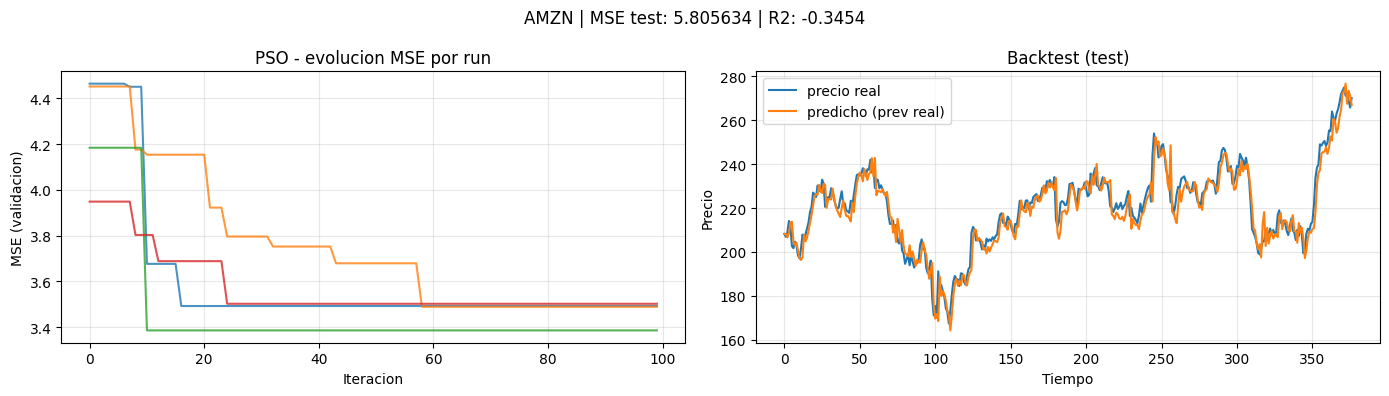

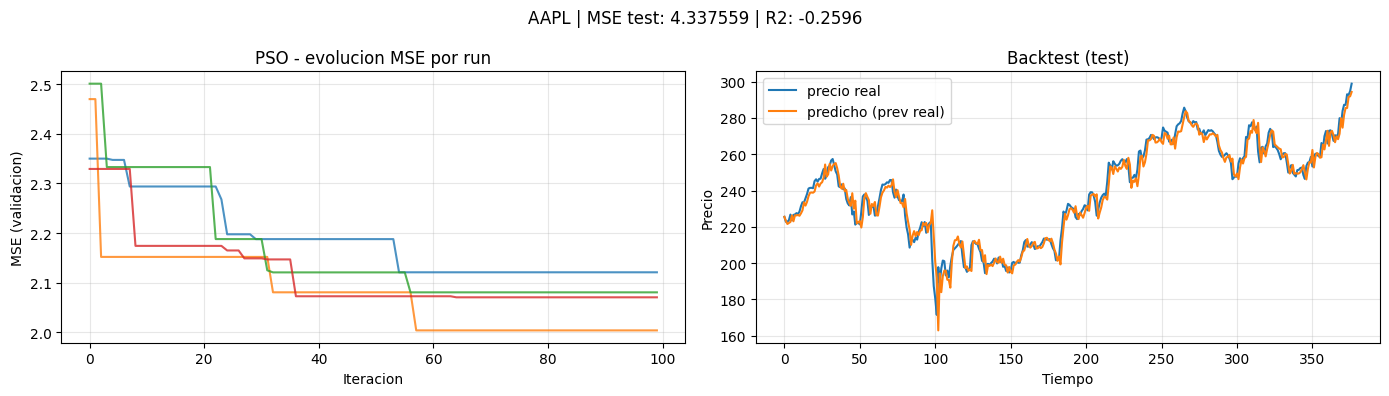

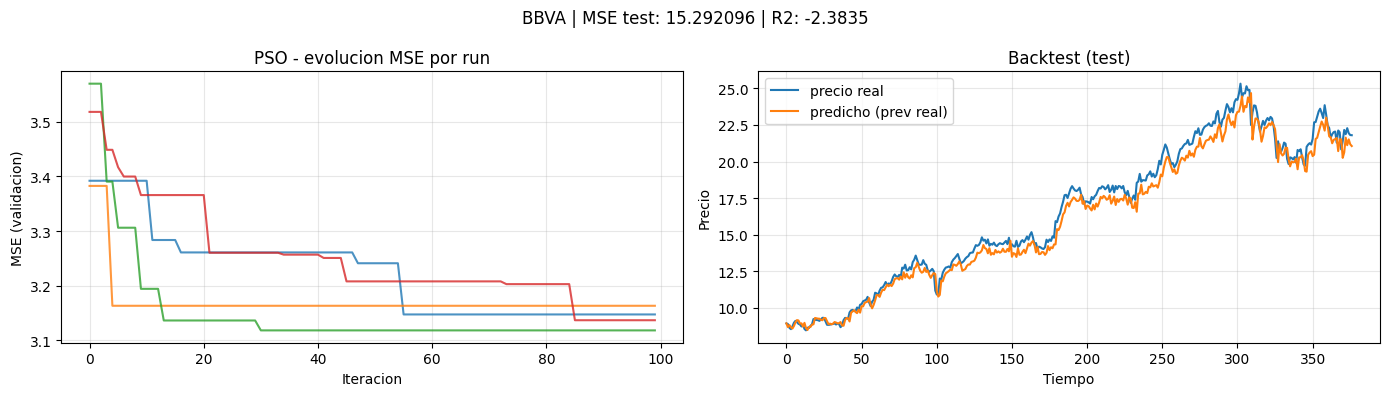

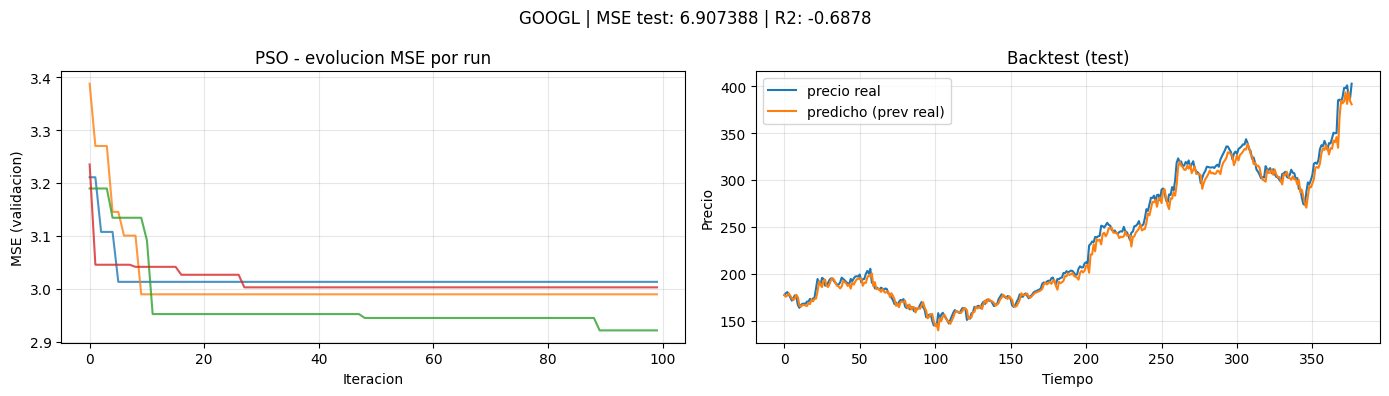

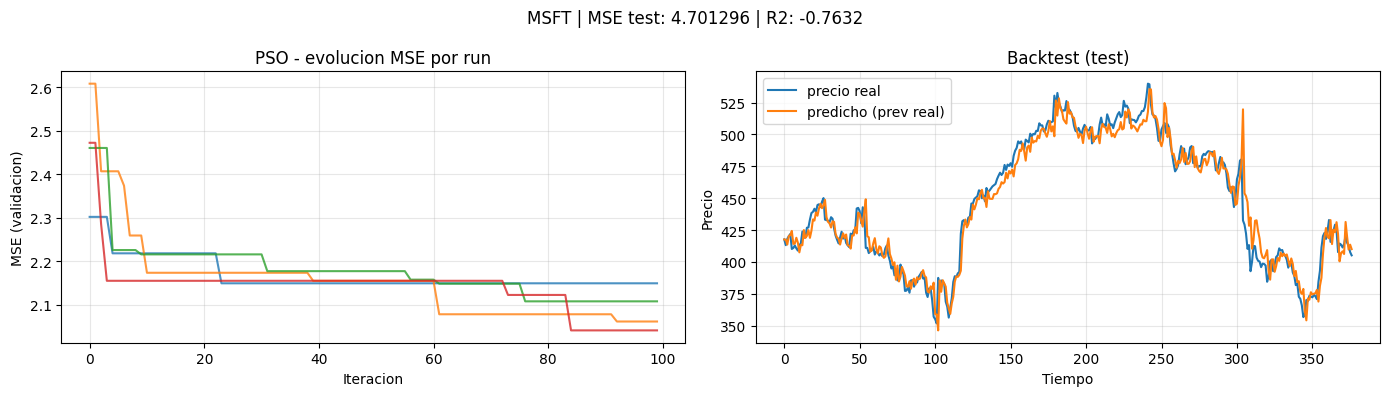

In [17]:
import matplotlib.pyplot as plt

def backtest_and_plot_ticker(ticker, splits, pso_result, model_base):
    # Preparar datos
    X_train_df = splits['train']['features']
    y_train_series = splits['train']['target']
    X_val_df = splits['val']['features']
    y_val_series = splits['val']['target']
    X_test_df = splits['test']['features']
    y_test_series = splits['test']['target']
    
    def _drop_nan_rows(X_df, y_series):
        mask = X_df.notna().all(axis=1) & y_series.notna()
        return X_df.loc[mask], y_series.loc[mask]
    
    X_train_df, y_train_series = _drop_nan_rows(X_train_df, y_train_series)
    X_val_df, y_val_series = _drop_nan_rows(X_val_df, y_val_series)
    X_test_df, y_test_series = _drop_nan_rows(X_test_df, y_test_series)
    
    if "Close" not in X_test_df.columns:
        raise ValueError("Close column not found in features; cannot build price backtest.")
    
    nombres_metricas = X_train_df.columns.values
    X_train = X_train_df.values
    X_val = X_val_df.values
    X_test = X_test_df.values
    y_train = numpy.asarray(y_train_series).ravel()
    y_val = numpy.asarray(y_val_series).ravel()
    y_test = numpy.asarray(y_test_series).ravel()
    close_test = X_test_df["Close"].values
    
    # Seleccionar mejores metricas del PSO
    best_mask = numpy.array(pso_result['mejor_mascara_absoluta'])
    selected_idx = numpy.where(best_mask == 1)[0]
    if len(selected_idx) == 0:
        print(f"{ticker}: PSO no selecciono metricas, se omite backtest.")
        return
    
    X_train_sel = X_train[:, selected_idx]
    X_val_sel = X_val[:, selected_idx]
    X_test_sel = X_test[:, selected_idx]
    
    # Entrenar modelo con train+val
    X_train_val = numpy.vstack((X_train_sel, X_val_sel))
    y_train_val = numpy.concatenate((y_train, y_val))
    model_base.fit(X_train_val, y_train_val)
    preds_test = model_base.predict(X_test_sel)
    mse_test = sklearn.metrics.mean_squared_error(y_test, preds_test)
    r2_test = sklearn.metrics.r2_score(y_test, preds_test)
    
    # Direccion de cambio
    actual_dir = numpy.sign(y_test)
    pred_dir = numpy.sign(preds_test)
    direction_accuracy = float((actual_dir == pred_dir).mean())
    
    # Reconstruccion de precios a partir de prediccion de cambio (porcentaje)
    real_price = close_test.copy()
    pred_price_real_prev = close_test.copy()
    pred_price_model_only = close_test.copy()
    for i in range(1, len(close_test)):
        pred_change = preds_test[i]
        factor = 1.0 + (pred_change / 100.0)
        pred_price_real_prev[i] = real_price[i - 1] * factor
        pred_price_model_only[i] = pred_price_model_only[i - 1] * factor
    
    # Construir figura
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"{ticker} | MSE test: {mse_test:.6f} | R2: {r2_test:.4f}")
    
    # Izquierda: evolucion del MSE por iteracion para cada run
    for run_stat in pso_result['estadisticas']:
        history = run_stat['cost_history']
        axes[0].plot(history, alpha=0.8)
    axes[0].set_title("PSO - evolucion MSE por run")
    axes[0].set_xlabel("Iteracion")
    axes[0].set_ylabel("MSE (validacion)")
    axes[0].grid(True, alpha=0.3)
    
    # Derecha: backtest con 3 curvas de precio
    axes[1].plot(real_price, label="precio real", linewidth=1.5)
    axes[1].plot(pred_price_real_prev, label="predicho (prev real)", linewidth=1.5)
    #axes[1].plot(pred_price_model_only, label="predicho (solo modelo)", linewidth=1.5)
    axes[1].set_title("Backtest (test)")
    axes[1].set_xlabel("Tiempo")
    axes[1].set_ylabel("Precio")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    selected_metrics = nombres_metricas[selected_idx]
    return {
        'mse_test': float(mse_test),
        'r2_test': float(r2_test),
        'direction_accuracy': float(direction_accuracy),
        'selected_metrics': list(selected_metrics)
    }


model = sklearn.ensemble.RandomForestRegressor(n_estimators=15, random_state=42, criterion='friedman_mse', n_jobs=-1)
backtest_summary = {}
for ticker in tickers:
    result = backtest_and_plot_ticker(ticker, processed_data[ticker], pso[ticker], model)
    if result is not None:
        backtest_summary[ticker] = result


Para comprobar fielmente esta sospecha, calculamos las métricas de R2 y acierto de dirección para cada acción, obteniendo un resumen tabular de los resultados. Estas métricas nos permitirán evaluar cuantitativamente el rendimiento del modelo y confirmar si realmente está aprendiendo información útil de los indicadores o simplemente siguiendo la tendencia general del precio. Puede observarse como el $R^2$ negativo en la mayoría de los casos confirma esta sospecha, indicando que el modelo no es capaz de explicar la variabilidad del precio a partir de las características seleccionadas, lo que sugiere que no está aprendiendo información útil de los indicadores. Además, predice el cambio de dirección correctamente sólo la mitad de las veces en la mayoría de los casos, lo que también sugiere que el modelo no está capturando patrones útiles para predecir la dirección del precio. En resumen, estas métr

In [19]:
# Tabla de R2 por ticker
r2_table = pandas.DataFrame(
    [(t, v.get('r2_test')) for t, v in backtest_summary.items()],
    columns=['ticker', 'r2_test']
).sort_values('r2_test', ascending=False).reset_index(drop=True)
print(r2_table)

# Tabla de acierto de direccion por ticker
direction_table = pandas.DataFrame(
    [(t, v.get('direction_accuracy')) for t, v in backtest_summary.items()],
    columns=['ticker', 'direction_accuracy']
).sort_values('direction_accuracy', ascending=False).reset_index(drop=True)
direction_table

  ticker   r2_test
0   AAPL -0.259624
1   AMZN -0.345450
2  GOOGL -0.687824
3   MSFT -0.763242
4   BBVA -2.383481


,ticker,direction_accuracy
0,AAPL,0.517241
1,MSFT,0.501326
2,AMZN,0.485411
3,GOOGL,0.482759
4,BBVA,0.442971
